In [1]:
# ============================================================
# [0] 데이터 다운로드 및 로드
# ============================================================
# 캘리포니아 주택 가격 데이터를 github에서 다운로드하고 pandas DataFrame으로 반환
# - Path: 파일 경로 객체. 파일 존재 여부 확인에 편리
# - tarfile: .tgz 압축 파일 해제
# - urllib.request.urlretrieve: URL에서 파일 다운로드
# ============================================================

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import numpy as np

def load_housing_data():
  tarball_path = Path("datasets/housing.tgz")
  if not tarball_path.is_file():
    Path("datasets").mkdir(parents=True, exist_ok=True)
    url="https://github.com/ageron/data/raw/main/housing.tgz"
    urllib.request.urlretrieve(url, tarball_path)
  with tarfile.open(tarball_path) as housing_tarball:
    housing_tarball.extractall(path="datasets")
  return pd.read_csv(Path("datasets/housing/housing.csv"))

housing=load_housing_data()

/tmp/ipykernel_1078/1031003072.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [2]:
# ============================================================
# [1] 계층적 샘플링을 위한 소득 카테고리 생성
# ============================================================
# 💡 핵심 개념: "계층적 샘플링(Stratified Sampling)"을 위한 사전 작업
# - median_income(중간 소득)은 연속값이라 그대로는 계층화 기준으로 못 씀
# - pd.cut()으로 5개의 구간으로 나눠 "income_cat"이라는 범주형 특성 생성
#   bins=[0, 1.5, 3.0, 4.5, 6.0, inf] → 구간 경계
#   labels=[1,2,3,4,5]               → 각 구간의 레이블
# - 목적: 훈련/테스트 세트에도 소득 분포 비율을 동일하게 유지하기 위함
# ============================================================

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [3]:
# ============================================================
# [2] 계층적 샘플링으로 훈련/테스트 세트 분할 🔑
# ============================================================
# 💡 핵심 개념: stratify 매개변수 = 계층적 샘플링의 핵심!
# - stratify=housing["income_cat"]: income_cat 비율을 train/test에 동일하게 유지
# - test_size=0.2: 전체의 20%를 테스트 세트로
# - random_state=42: 재현성 보장 (같은 결과를 다시 얻기 위함)
#
# ⚠️ 왜 계층적 샘플링을 쓰는가?
# - 단순 무작위 샘플링 시 특정 소득 구간이 과/소 표집될 수 있음
# - 중간 소득은 집값과 강한 상관관계가 있으므로 편향되면 평가가 부정확
# ============================================================

from sklearn.model_selection import train_test_split
strat_train_set, strat_test_set=train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [4]:
# ============================================================
# [3] 이제 계층화 기준을 사용했으니 income_cat 삭제
# ============================================================
# - 샘플링 용도로만 쓴 임시 특성이므로 제거해 원본 상태로 복원
# - inplace=True: 원본 DataFrame을 직접 수정 (반환값 None)
# - axis=1: 열(column) 삭제 (axis=0이면 행)
# ============================================================

for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

In [5]:
# ============================================================
# [4] 데이터 탐색용 복사본 생성
# ============================================================
# - 원본 strat_train_set을 건드리지 않기 위해 copy()로 복사
# - 이후 시각화, 상관관계 분석, 특성 조합 등을 자유롭게 실험
# ============================================================

housing=strat_train_set.copy()

In [6]:
# ============================================================
# [5] 상관관계 행렬 계산
# ============================================================
# 💡 핵심 개념: 피어슨 상관계수 (Pearson correlation coefficient)
# - -1 ~ 1 사이의 값:
#     1에 가까울수록 강한 양의 선형 관계
#    -1에 가까울수록 강한 음의 선형 관계
#     0에 가까울수록 선형 관계 없음
# - numeric_only=True: 수치형 특성만 계산 (object 타입 제외)
# - ⚠️ 주의: 선형 관계만 포착. 비선형 관계(예: 곡선)는 잡지 못함
# ============================================================

corr_matrix=housing.corr(numeric_only=True)

In [7]:
# ============================================================
# [6] 타깃(median_house_value)과의 상관관계 확인
# ============================================================
# - 집값 예측에 가장 도움되는 특성을 찾기 위해 정렬
# - median_income이 가장 높은 상관계수를 보임 (약 0.69)
#   → 중간 소득이 올라갈수록 집값도 올라감
# ============================================================

corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


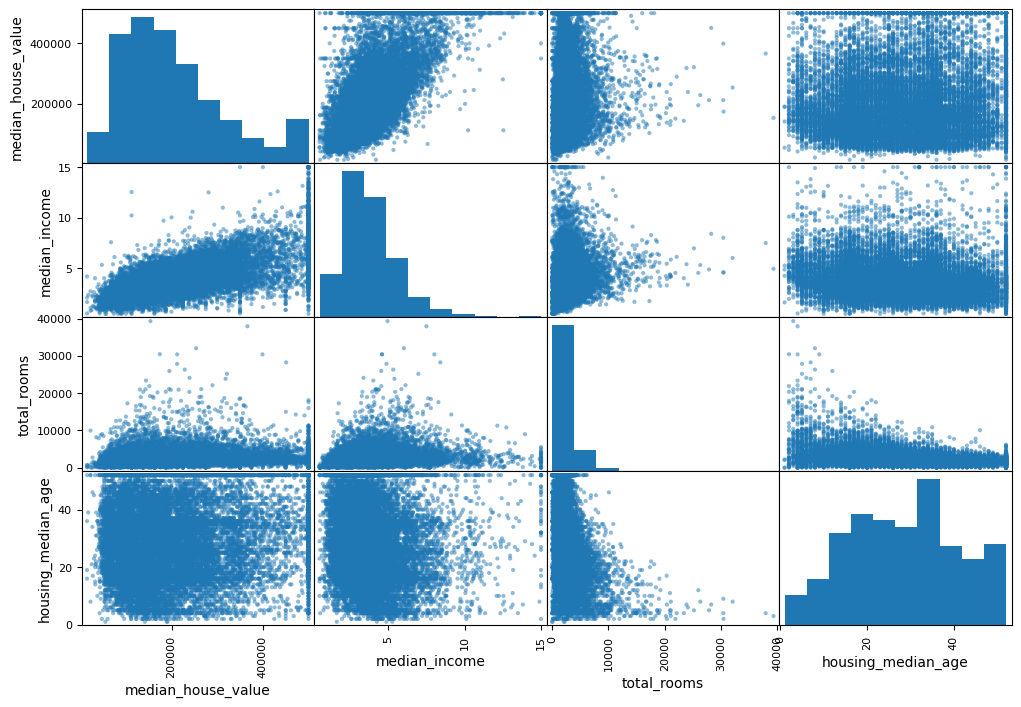

In [8]:
# ============================================================
# [7] 산점도 행렬(scatter matrix)로 여러 특성 간 관계 시각화
# ============================================================
# - 상관관계가 높은 4개 특성을 골라 서로의 관계를 한눈에 확인
# - 대각선은 해당 특성의 히스토그램
# - 비선형 관계나 이상치 패턴 발견에 유용
# ============================================================

from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

attributes=["median_house_value", "median_income", "total_rooms",
            "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46301 (\N{HANGUL SYLLABLE DEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

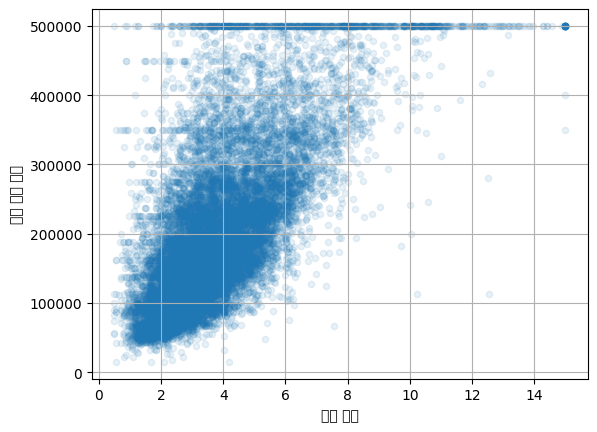

In [9]:
# ============================================================
# [8] 가장 중요한 특성 조합 확대해서 시각화
# ============================================================
# - median_income vs median_house_value 상세 확인
# - alpha=0.1: 투명도. 점이 많이 겹치는 곳의 밀집도 표현
# - 👁️ 관찰 포인트: 500,000 부근의 수평선 = 집값이 인위적으로 절단된 구간
#   (데이터 수집 과정에서 상한선을 적용한 흔적)
# ============================================================

housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.xlabel("중간 소득")
plt.ylabel("중간 주택 가격")
plt.show()

In [10]:
# ============================================================
# [9] 💡 특성 조합(feature engineering) - 새로운 의미있는 특성 생성
# ============================================================
# 원본 특성보다 "비율"이 더 유용한 경우가 많음:
# - rooms_per_house: 가구당 방 개수 (구역 크기와 무관한 지표)
# - bedrooms_ratio: 전체 방 중 침실 비율 (집의 구성)
# - population_per_house: 가구당 인원수 (밀집도)
#
# 👁️ 이렇게 만든 비율 특성들이 원본보다 타깃과 상관이 더 높을 수 있음!
# ============================================================

housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_house"] = housing["population"] / housing["households"]

In [11]:
# ============================================================
# [10] 🔑 특성(X)과 레이블(y) 분리 - 머신러닝의 시작
# ============================================================
# - housing: 입력 특성만 담은 DataFrame (median_house_value 제거)
# - housing_labels: 예측해야 할 타깃 = 정답 레이블
# - .copy(): 원본과 독립된 복사본 (SettingWithCopyWarning 방지)
# ============================================================

housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [12]:
# ============================================================
# [11] 💡 핵심 개념: 결측치(missing value) 처리의 3가지 방법
# ============================================================
# total_bedrooms 열에 결측치(NaN)가 있을 때 가능한 선택지:
#
# 방법 1: 결측치가 있는 행(구역) 제거
#   housing.dropna(subset=["total_bedrooms"], inplace=True)
#   → 데이터 손실 발생
#
# 방법 2: 전체 열(특성) 제거
#   housing.drop("total_bedrooms", axis=1, inplace=True)
#   → 유용한 특성을 통째로 잃음
#
# 방법 3: 어떤 값으로 채우기 (중간값, 평균, 0 등) ✅ 가장 권장
#   median = housing["total_bedrooms"].median()
#   housing["total_bedrooms"].fillna(median, inplace=True)
#   → 정보 손실 최소화
# ============================================================

housing.dropna(subset=["total_bedrooms"], inplace=True)
# housing.drop("total_bedrooms", axis=1, inplace=True)
median=housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace=True)

/tmp/ipykernel_1078/1032051045.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace=True)


In [13]:
# ============================================================
# [12] 🔑 SimpleImputer - 결측치 처리를 자동화/표준화
# ============================================================
# 💡 왜 직접 fillna() 대신 SimpleImputer를 쓸까?
# - 훈련 세트의 중간값을 "학습"해 테스트 세트/새 데이터에도 동일 적용 가능
# - 파이프라인으로 다른 전처리와 자연스럽게 연결
# - 데이터 누수(data leakage) 방지
#
# strategy 옵션: "median", "mean", "most_frequent", "constant"
# ============================================================

from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")

In [14]:
# ============================================================
# [13] 수치형 특성만 선택 (SimpleImputer는 숫자만 처리 가능)
# ============================================================
# - select_dtypes(include=[np.number]): 수치 타입 열만 골라냄
# - ocean_proximity 같은 object(문자열) 타입은 제외됨
# ============================================================

housing_num=housing.select_dtypes(include=[np.number])

In [15]:
# ============================================================
# [14] 🔑 fit() - 훈련 데이터로 "중간값 학습"
# ============================================================
# 💡 사이킷런 API의 핵심 패턴: fit() → transform()
# - fit(): 데이터로부터 필요한 통계량 학습 (여기선 각 열의 중간값)
# - 학습된 값은 imputer.statistics_ 속성에 저장됨
# ============================================================

imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [16]:
# [15] 학습된 중간값 확인 - 각 열별로 저장됨

imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.5   ,  434.    , 1167.    ,
        408.5   ,    3.5409])

In [17]:
# [16] housing_num.median().values와 비교 → 동일함을 확인
#      (imputer가 실제로 중간값을 잘 학습했는지 검증)

housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.5   ,  434.    , 1167.    ,
        408.5   ,    3.5409])

In [18]:
# ============================================================
# [17] 🔑 transform() - 학습한 중간값으로 실제 변환 수행
# ============================================================
# - X는 NumPy 배열 (DataFrame 아님!)
# - fit()과 transform()을 한번에 하려면 fit_transform() 사용
# ============================================================

X = imputer.transform(housing_num)

In [19]:
# [18] 변환된 NumPy 배열을 다시 DataFrame으로 복원 (열 이름, 인덱스 유지)

housing_tr = pd.DataFrame(X, columns = housing_num.columns,
                          index = housing_num.index)

In [20]:
# ============================================================
# [19] 범주형(categorical) 특성 처리 시작
# ============================================================
# - ocean_proximity는 문자열 범주형 특성 (<1H OCEAN, INLAND, 등)
# - 머신러닝 모델은 숫자만 처리하므로 인코딩 필요!
# - housing[["ocean_proximity"]]: 이중 대괄호 → DataFrame 형태로 유지 (2D)
# ============================================================

housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [21]:
# ============================================================
# [20] ⚠️ OrdinalEncoder - 순서형 인코딩 (주의해서 사용!)
# ============================================================
# - 각 범주에 정수(0, 1, 2, ...) 할당
# - 알파벳 순서로 자동 정렬됨
# ============================================================

from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()
housing_cat_encoded=ordinal_encoder.fit_transform(housing_cat)

In [22]:
# [21] 인코딩 결과 확인 - 각 샘플이 0~4의 정수로 변환됨

housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [23]:
# ============================================================
# [22] ⚠️ OrdinalEncoder의 문제점 확인
# ============================================================
# categories_ = ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']
#                    0           1          2         3            4
#
# 🚨 문제: 모델은 숫자의 순서/크기에 의미가 있다고 가정!
# - 0(<1H OCEAN)과 4(NEAR OCEAN)는 실제로 비슷한 지역인데 "가장 멀다"고 해석
# - 0과 1(INLAND)은 완전 다른 지역인데 "가깝다"고 해석
# → 순서가 없는 범주형에는 OneHotEncoder를 써야 함!
# ============================================================

ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [24]:
# ============================================================
# [23] ✅ OneHotEncoder - 순서 없는 범주형의 올바른 해결책
# ============================================================
# 💡 각 범주를 독립된 이진 열(0 또는 1)로 변환
# - 5개 범주 → 5개 열 생성
# - 해당 범주일 때만 1, 나머지는 0 (그래서 "one-hot")
# - 모든 범주 간 거리가 동일 → 잘못된 순서 가정 없음
# ============================================================

from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [25]:
# [24] 결과는 희소 행렬(sparse matrix) - 메모리 효율적
#      (대부분이 0이므로 0이 아닌 위치만 저장)

housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16344 stored elements and shape (16344, 5)>

In [26]:
# [25] toarray()로 일반 NumPy 배열로 변환해서 확인
#      각 행에 1이 딱 하나씩 있는 one-hot 형태 확인 가능

housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [27]:
# [26] 학습된 범주 목록 확인

cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [28]:
# [27] 💡 판다스 get_dummies()로도 원-핫 인코딩 가능
#      - 간편하지만 새 데이터의 범주를 처리할 때 일관성 문제 발생 가능
#      - 사이킷런 OneHotEncoder가 파이프라인과 더 호환성 좋음

df_test=pd.DataFrame({"ocean_proximity":["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [29]:
# [28] 같은 작업을 OneHotEncoder로 - 일관된 인코딩

cat_encoder.transform(df_test).toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [30]:
# ============================================================
# [29] ⚠️ get_dummies의 한계: 학습되지 않은 범주 처리 문제
# ============================================================
# - "<2H OCEAN"은 훈련 데이터에 없던 새 범주
# - get_dummies는 새 범주를 위한 열을 만들어버려 훈련 때와 열 구조가 달라짐
# - OneHotEncoder는 handle_unknown="ignore"로 무시 가능 → 더 안전!
# ============================================================

df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


In [31]:
# ============================================================
# [30] 🔑 특성 스케일링 1: MinMaxScaler (정규화, Normalization)
# ============================================================
# 💡 공식: x_scaled = (x - min) / (max - min)
# - 기본: [0, 1] 범위로 변환
# - feature_range=(-1, 1): 범위를 [-1, 1]로 조정 (신경망에 주로 사용)
# - ⚠️ 이상치에 매우 민감 (outlier 하나가 나머지 값들을 찌그러뜨림)
# ============================================================

from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled=min_max_scaler.fit_transform(housing_num)

In [32]:
# ============================================================
# [31] 🔑 특성 스케일링 2: StandardScaler (표준화, Standardization)
# ============================================================
# 💡 공식: x_scaled = (x - mean) / std
# - 결과: 평균 0, 표준편차 1
# - 범위 제한 없음
# - ✅ 이상치에 상대적으로 덜 민감 → 실전에서 더 많이 사용
# ============================================================

from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()
housing_num_std_scaled=std_scaler.fit_transform(housing_num)

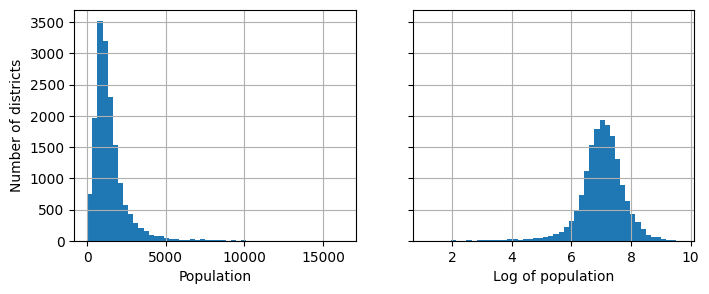

In [33]:
# ============================================================
# [32] 💡 로그 변환 - 꼬리가 긴 분포를 정규분포에 가깝게
# ============================================================
# population 같은 특성은 "소수가 매우 큼" 분포 (long-tailed)
# - 왼쪽: 원본 population (오른쪽으로 치우침)
# - 오른쪽: log(population) (대칭적인 정규분포 형태)
#
# 왜 로그 변환?
# - 많은 ML 알고리즘이 정규분포를 가정하거나 선호
# - 극단값의 영향 축소
# ============================================================

fit, axs=plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
plt.show()

In [34]:
# ============================================================
# [33] 💡 RBF 커널(가우시안 방사 기저 함수)로 "유사도" 특성 만들기
# ============================================================
# - rbf_kernel(X, [[35]]): 각 값이 35와 얼마나 가까운지를 0~1 값으로 반환
# - gamma: 유사도가 급격하게 떨어지는 정도 (클수록 가까운 값만 1에 가까움)
# - 예: "35년 된 집과의 유사도"라는 새 특성 생성 가능
# ============================================================

from sklearn.metrics.pairwise import rbf_kernel
age_simil_35=rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

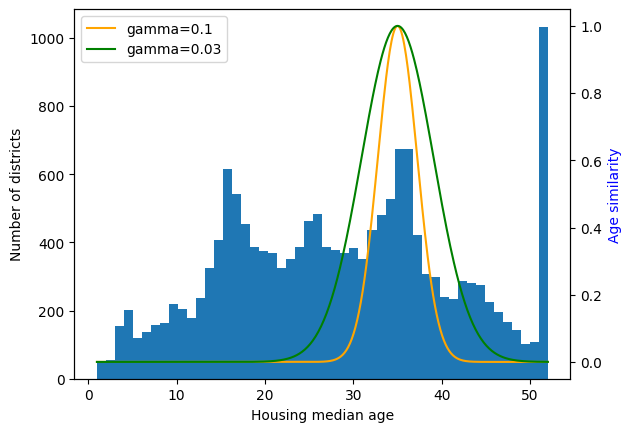

In [35]:
# [34] gamma 값에 따라 유사도 곡선이 어떻게 달라지는지 시각화
#      - gamma=0.1: 35 근처에서 급격히 감소 (좁은 종 모양)
#      - gamma=0.03: 완만하게 감소 (넓은 종 모양)

ages=np.linspace(housing["housing_median_age"].min(),
                 housing["housing_median_age"].max(),
                 500).reshape(-1, 1)
gamma1=0.1
gamma2=0.03
rbf1=rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2=rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2=ax1.twinx()

ax2.plot(ages, rbf1, color='orange', label="gamma=0.1")
ax2.plot(ages, rbf2, color='green', label="gamma=0.03")
ax2.tick_params(axis='y')
ax2.set_ylabel("Age similarity", color='blue')

plt.legend(loc="upper left")
plt.show()

In [36]:
# [35] 💡 전체 파이프라인 적용을 위해 X(특성)와 y(레이블) 다시 준비

housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"]

In [37]:
# ============================================================
# [36] 💡 타깃(y)도 스케일링해야 할까? - 수동 방식
# ============================================================
# 일부 알고리즘은 타깃값의 크기에도 민감 → 스케일링 필요
# 하지만 예측값을 원래 단위로 "역변환"해야 실제로 쓸 수 있음
# - fit_transform: 타깃 스케일링 학습 및 변환
# - inverse_transform: 예측값을 원래 달러 단위로 복원
# ============================================================

from sklearn.linear_model import LinearRegression
target_scaler=StandardScaler()
scaled_labels=target_scaler.fit_transform(housing_labels.to_frame())
model=LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data=housing[["median_income"]].iloc[:5]
scaled_predictions=model.predict(some_new_data)
predictions=target_scaler.inverse_transform(scaled_predictions)

In [38]:
# ============================================================
# [37] ✅ TransformedTargetRegressor - 타깃 스케일링 자동화
# ============================================================
# 위의 수동 과정을 한 번에 처리:
# - 타깃을 자동으로 스케일링해서 학습
# - predict() 시 자동으로 역변환해 원래 단위로 반환
# → 실수 가능성 줄이고 코드 간결화
# ============================================================

from sklearn.compose import TransformedTargetRegressor

model=TransformedTargetRegressor(LinearRegression(),
                                 transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions=model.predict(some_new_data)

In [39]:
# ============================================================
# [38] 💡 FunctionTransformer - 함수를 변환기로 래핑
# ============================================================
# 사용자 정의 변환을 사이킷런 파이프라인과 호환되게 만듦
# - np.log: 로그 변환 함수
# - inverse_func=np.exp: 역변환 함수 (지수)
# - 파이프라인에 포함 가능, fit은 아무것도 안 함 (단순 함수 적용)
# ============================================================

from sklearn.preprocessing import FunctionTransformer

log_transformer=FunctionTransformer(np.log, inverse_func=np.exp)
log_pop=log_transformer.transform(housing[["population"]])

In [40]:
# [39] FunctionTransformer로 RBF 커널도 변환기화
#      kw_args로 함수의 추가 키워드 인자 전달

rbf_transformer=FunctionTransformer(rbf_kernel,
                                    kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35=rbf_transformer.transform(housing[["housing_median_age"]])

In [41]:
# [40] 💡 흥미로운 응용: 샌프란시스코와의 지리적 유사도 특성!
#      - 위도/경도 → 특정 지점(SF)과의 거리 유사도로 변환
#      - 도심 근접도가 집값에 영향을 주므로 유용한 특성

sf_coords=37.7749, -122.41
sf_transformer=FunctionTransformer(rbf_kernel,
                                    kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil=sf_transformer.transform(housing[["latitude", "longitude"]])

In [42]:
# [41] 💡 lambda로 즉석 변환기 만들기 - 두 열의 비율
#      예: [X[:, 0] / X[:, 1]] → bedrooms/rooms 같은 비율 계산

ratio_transformer=FunctionTransformer(lambda X:X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

In [43]:
# ============================================================
# [42] 🔑 커스텀 변환기 만들기 - StandardScaler 직접 구현
# ============================================================
# 💡 사이킷런과 호환되는 변환기 만드는 법:
# 1. BaseEstimator 상속 → get_params(), set_params() 자동 제공
# 2. TransformerMixin 상속 → fit_transform() 자동 제공
# 3. fit(X, y=None): self 반환 필수
# 4. transform(X): 변환된 데이터 반환
#
# check_array(): 입력이 올바른 NumPy 배열인지 검증
# check_is_fitted(): fit()이 호출됐는지 검증
# 관례: 학습된 속성 이름은 뒤에 언더스코어 _ 붙임 (mean_, scale_)
# ============================================================

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
  def __init__(self, with_mean=True):
    self.with_mean=with_mean

  def fit(self, X, y=None):
    X=check_array(X)
    self.mean_=X.mean(axis=0)
    self.scale_=X.std(axis=0)
    self.n_features_in_=X.shape[1]
    return self

  def transform(self, X):
    check_is_fitted(self)
    X=check_array(X)
    assert self.n_features_in_ == X.shape[1]
    if self.with_mean:
      X=X-self.mean_
    return X/self.scale_

In [44]:
# ============================================================
# [43] 🔑 실전 커스텀 변환기: ClusterSimilarity (지리 클러스터 유사도)
# ============================================================
# 💡 아이디어: 위도/경도를 K-Means로 클러스터링한 뒤,
#           각 샘플이 각 클러스터 중심과 얼마나 가까운지를 특성으로 사용
#
# - n_clusters=10: 10개의 중심점 생성
# - gamma=1.0: RBF 커널의 감쇠 정도
# - fit(): K-Means로 클러스터 중심 학습 (sample_weight로 집값 가중치 반영 가능)
# - transform(): 각 샘플과 모든 클러스터 중심 간 RBF 유사도 계산
#
# → 결과: 위도/경도 2개 특성 → 10개의 "클러스터 유사도" 특성으로 확장
# ============================================================

from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
  def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
    self.n_clusters=n_clusters
    self.gamma=gamma
    self.random_state=random_state

  def fit(self, X, y=None, sample_weight=None):
    self.kmeans_=KMeans(self.n_clusters, random_state=self.random_state)
    self.kmeans_.fit(X, sample_weight=sample_weight)
    return self

  def transform(self, X):
    return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

  def get_features_names_out(self, names=None):
    return [f"클러스터 {i} 유사도" for i in range(self.n_clusters)]

In [45]:
# [44] ClusterSimilarity 적용
#      sample_weight=housing_labels: 집값이 높은 지역에 더 중요하게 클러스터링

cluster_simil=ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities=cluster_simil.fit_transform(housing[["latitude", "longitude"]],
                                         sample_weight=housing_labels)

In [46]:
# [45] 처음 3개 샘플의 10개 클러스터 유사도 값 확인
#      각 행에서 가장 큰 값이 해당 샘플이 속한(가장 가까운) 클러스터

similarities[:3].round(2)

array([[0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.13, 0.55, 0.  , 0.56],
       [0.64, 0.  , 0.11, 0.04, 0.  , 0.  , 0.  , 0.  , 0.99, 0.  ],
       [0.  , 0.65, 0.  , 0.  , 0.01, 0.  , 0.49, 0.59, 0.  , 0.28]])

In [47]:
# [46] 한글 폰트 설치 (matplotlib에서 한글 깨짐 방지)

!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 41.8 MB/s eta 0:00:00


In [48]:
# [47] 한글 폰트 적용

import koreanize_matplotlib

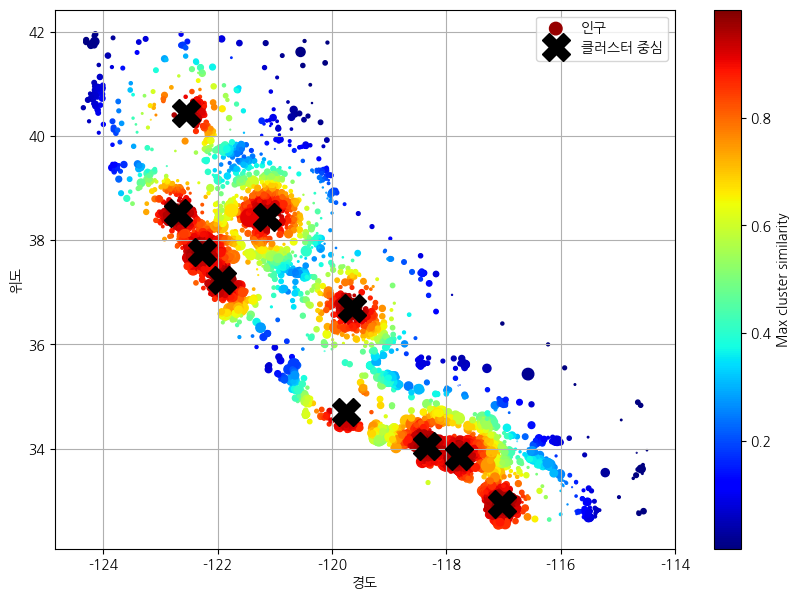

In [49]:
# [48] 💡 클러스터링 결과 시각화
#      - 점 크기: 인구 수
#      - 점 색상: 최대 클러스터 유사도 (가장 가까운 클러스터에 얼마나 가까운지)
#      - X 마커: 클러스터 중심점 10개

housing_renamed=housing.rename(columns={
    "latitude":"Latitude", "longitude":"Longitude",
    "population":"Population",
    "median_house_value":"Median house value (USD)"
})
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude",
                     grid=True, s=housing_renamed["Population"]/100,
                     label="인구", c="Max cluster similarity",
                     cmap="jet", colorbar=True, legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="클러스터 중심")
plt.xlabel('경도')
plt.ylabel('위도')
plt.legend(loc="upper right")
plt.show()

In [50]:
# ============================================================
# [49] 🔑 Pipeline - 여러 전처리 단계를 하나로 묶기
# ============================================================
# 💡 왜 파이프라인을 쓸까?
# 1. 코드 간결화 (하나의 fit/predict 호출로 전체 처리)
# 2. 데이터 누수 방지 (훈련/테스트에 일관된 처리)
# 3. 교차 검증, 그리드 서치와 자연스럽게 연동
#
# Pipeline([...]): 각 단계에 이름 직접 지정
# make_pipeline(...): 클래스명 기반으로 이름 자동 생성 (더 간편)
#
# 여기서는: 중간값 대체 → 표준화 순서로 자동 처리
# ============================================================

from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy = "median")),
    ("standardize", StandardScaler()),
])

from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy = "median"), StandardScaler())

housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.36,  0.14,  1.4 , -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [51]:
# [50] 전처리된 결과를 DataFrame으로 변환해 확인
#      get_feature_names_out(): 파이프라인을 거친 후의 특성 이름 반환

df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns = num_pipeline.get_feature_names_out(),
    index = housing_num.index
)

df_housing_num_prepared.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.422634,1.013124,1.860687,0.310661,1.359094,0.137572,1.395732,-0.937557
14973,0.596681,-0.702274,0.907526,-0.308789,-0.436356,-0.693276,-0.373537,1.171380


In [52]:
# ============================================================
# [51] 🔑 ColumnTransformer - 열마다 다른 전처리 적용
# ============================================================
# 💡 실전에서는 수치형/범주형 특성에 다른 전처리가 필요!
# - num_pipeline: 수치형 열들에 적용 (중간값 대체 + 표준화)
# - cat_pipeline: 범주형 열들에 적용 (최빈값 대체 + 원-핫 인코딩)
#   handle_unknown="ignore": 새 범주 만나도 에러 없이 모두 0으로 처리
#
# ColumnTransformer가 두 파이프라인을 병렬로 적용하고 결과를 합침
# ============================================================

from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy = "most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [53]:
# ============================================================
# [52] 💡 make_column_selector + make_column_transformer - 더 간결한 방식
# ============================================================
# - make_column_selector(dtype_include=np.number): 수치형 열 자동 선택
# - make_column_selector(dtype_include=object): 문자열 열 자동 선택
# → 열 이름을 일일이 적지 않아도 됨!
# ============================================================

from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

housing_prepared = preprocessing.fit_transform(housing)

df_housing_prepared = pd.DataFrame(
    housing_prepared, columns = preprocessing.get_feature_names_out(),
    index=housing.index
)

df_housing_prepared.head(5)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,0.0,1.0,0.0,0.0,0.0
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,0.0,1.0,0.0,0.0,0.0
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,0.0,0.0,0.0,0.0,1.0


In [54]:
# ============================================================
# [53] 🔑 책의 '종합 전처리 파이프라인' - 실전의 정점!
# ============================================================
# 💡 각 특성에 최적화된 전처리를 한꺼번에 적용
#
# 📌 헬퍼 함수
# - column_ratio: 두 열의 비율 계산 (예: bedrooms/rooms)
# - ratio_name: 변환 결과의 특성 이름 지정
# - ratio_pipeline(): 결측치 대체 + 비율 계산 + 표준화
#
# 📌 ColumnTransformer 구성 (각 파이프라인이 담당하는 역할)
# - bedrooms       : 침실/전체방 비율
# - rooms_per_house: 가구당 방 개수
# - peope_per_house: 가구당 인원
# - log            : 꼬리긴 분포 5개 특성에 로그 변환
# - geo            : 위도/경도 → 10개의 클러스터 유사도
# - cat            : 범주형(ocean_proximity) → 원-핫 인코딩
# - remainder      : 나머지(housing_median_age) → 기본 처리
#
# 🎯 최종 효과: 원본 10개 특성 → 20개 이상의 의미있는 특성으로 확장
# ============================================================

def column_ratio(X):
  return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
  return ["ratio"]

def ratio_pipeline():
  return make_pipeline(
      SimpleImputer(strategy = "median"),
      FunctionTransformer(column_ratio, feature_names_out = ratio_name),
      StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy = "median"),
    FunctionTransformer(np.log, feature_names_out = "one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma = 1, random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("peope_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                           "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline)

In [55]:
# [54] 전체 파이프라인 적용 후 shape 확인
#      열 개수가 크게 늘어났음을 볼 수 있음 (특성 확장의 효과)

housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 24)

In [56]:
# ============================================================
# [55] 🔑 모델 1: 선형 회귀 (Linear Regression)
# ============================================================
# 💡 전처리 + 모델을 하나의 파이프라인으로 묶는 것이 핵심!
# - make_pipeline(preprocessing, LinearRegression())
# - fit(housing, housing_labels): 전처리 학습 + 모델 학습 한 번에
# - predict(housing): 전처리 적용 + 예측 한 번에
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

lin_reg = make_pipeline(preprocessing, LinearRegression())

lin_reg.fit(housing, housing_labels)

housing_predictions = lin_reg.predict(housing)

housing_predictions[:5].round(-2)

array([246000., 372700., 135700.,  91400., 330900.])

In [57]:
# [56] 실제 레이블값과 비교해보기 (처음 5개 샘플)

housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [58]:
# ============================================================
# [57] 🔑 RMSE (Root Mean Squared Error) - 회귀 평가 지표
# ============================================================
# 💡 공식: RMSE = sqrt( mean( (예측값 - 실제값)^2 ) )
# - 단위가 타깃과 동일 (달러)
# - 큰 오차에 더 강한 페널티 (제곱이라서)
# - 예: RMSE가 $68,000 → 예측이 평균적으로 $68,000 정도 빗나감
#
# ⚠️ 훈련 세트 RMSE만 보면 과소적합/과대적합 판단 불가
#    → 교차 검증으로 확인 필요!
# ============================================================

from sklearn.metrics import mean_squared_error

lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)

print(float(lin_rmse))

68972.88910758484


In [59]:
# ============================================================
# [58] 🔑 모델 2: 결정 트리 회귀 (Decision Tree Regressor)
# ============================================================
# 💡 특징:
# - 비선형 관계 포착 가능
# - 특성 스케일링에 둔감
# - ⚠️ 매우 과대적합되기 쉬움 → 훈련 RMSE가 0에 가까울 수 있음!
#
# 여기서 RMSE=0 → 훈련 세트를 완전히 외움 → 새 데이터엔 못 쓸 모델!
# ============================================================

from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state = 42))
tree_reg.fit(housing, housing_labels)

housing_predictions = tree_reg.predict(housing)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)

print(float(tree_rmse))

0.0


In [60]:
# ============================================================
# [59] 🔑 K-Fold 교차 검증 (Cross Validation)
# ============================================================
# 💡 핵심 아이디어:
# - 훈련 세트를 K개 폴드로 나눔 (cv=10)
# - K번 반복: 1개 폴드로 검증, 나머지 K-1개로 학습
# - 결과: K개의 평가 점수
#
# 장점:
# - 테스트 세트를 건드리지 않고도 모델의 일반화 성능 추정
# - 평균뿐 아니라 성능의 분산(표준편차)도 알 수 있음
#
# scoring="neg_root_mean_squared_error": 사이킷런은 점수가 클수록 좋다는 관례
# → RMSE에 음수를 붙임 → 결과에 다시 - 붙여 양수로 복원
# ============================================================

from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [61]:
# ============================================================
# [60] 결정 트리의 진짜 성능 확인!
# ============================================================
# - describe(): 10번 검증 결과의 평균, 표준편차 등 확인
# - 훈련 RMSE=0 이었는데 교차검증 RMSE는 매우 높음
# → 명백한 과대적합! 결정 트리는 이 문제에 부적합
# ============================================================

pd.Series(tree_rmses).describe()

,0
count,10.000000
mean,66573.734600
std,1103.402323
min,64607.896046
25%,66204.731788
50%,66388.272499
75%,66826.257468
max,68532.210664


In [62]:
# ============================================================
# [61] 💡 모델 3: 랜덤 포레스트 (Random Forest)
# ============================================================
# - 여러 개의 결정 트리를 앙상블(조합)한 모델
# - 각 트리가 서로 다른 샘플/특성으로 학습 → 과대적합 완화
# - 결정 트리보다 훨씬 좋은 성능, 캘리포니아 주택 예측에 적합
# - 주석 처리된 코드는 실행 시간이 길어 생략된 부분
# ============================================================

from sklearn.ensemble import RandomForestRegressor
# from sklearn.pipeline import make_pipeline

# forest_reg = make_pipeline(preprocessing,
#                            RandomForestRegressor(random_state=42))
# forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
#                                 scoring = "neg_root_mean_squared_error", cv=10)
# pd.Series(forest_rmses).describe()

In [63]:
# ============================================================
# [62] 🔑 GridSearchCV - 모든 하이퍼파라미터 조합 완전 탐색
# ============================================================
# 💡 이중 파이프라인 구조:
# - preprocessing (전처리) + random_forest (모델)
# - param_grid의 key는 "단계이름__하이퍼파라미터" 형식 (언더스코어 2개!)
#
# 📌 탐색 대상:
# - preprocessing__geo__n_clusters: 클러스터 개수 (전처리 하이퍼파라미터!)
# - random_forest__max_features: 각 트리가 보는 특성 수
#
# ✨ 하이퍼파라미터 2가지 그룹을 각각 탐색:
# - 첫 그리드: 3×3 = 9조합
# - 둘째 그리드: 2×3 = 6조합
# - 총 15조합 × cv=3 = 45번 학습
# ============================================================

from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters':[5, 8, 10],
     'random_forest__max_features':[4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7cb1e3557260>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [64]:
# [63] 최적 하이퍼파라미터 조합 확인

grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [65]:
# [64] 교차 검증 결과를 DataFrame으로 정리해서 비교

cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score",
                 "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_featires"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_featires,split0,split1,split2,mean_test_rmse
12,15,6,42725,43708,44335,43590
13,15,8,43486,43820,44900,44069
6,10,4,43798,44036,44961,44265
9,10,6,43710,44163,44967,44280
7,10,6,43710,44163,44967,44280


In [66]:
# ============================================================
# [65] 🔑 RandomizedSearchCV - 확률 분포에서 랜덤 샘플링
# ============================================================
# 💡 GridSearchCV와 차이점:
# - 지정된 분포에서 무작위로 조합을 n_iter번 샘플링
# - randint(low=3, high=50): 3~49 범위의 정수에서 무작위 선택
# - 탐색 횟수를 직접 제어 가능 (여기선 10번)
#
# 언제 써야?
# - 하이퍼파라미터가 많거나 탐색 범위가 넓을 때
# - 연속적인 값을 탐색하고 싶을 때
# - 계산 예산(시간)이 제한적일 때
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}
rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb1e58e15e0>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cb1e0bd9370>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [67]:
# [66] 랜덤 탐색 결과 정리

# 랜덤 탐색 결과 출력
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41342,42242,43057,42214
8,32,7,41825,42275,43241,42447
0,41,16,42238,42938,43354,42843
5,42,4,41869,43362,43664,42965
2,23,8,42490,42928,43718,43046


In [68]:
# ============================================================
# [67] 💡 최종 모델 선택 & 특성 중요도 확인
# ============================================================
# - best_estimator_: 검증 성능이 가장 좋았던 파이프라인 전체
# - feature_importances_: 랜덤 포레스트가 판단한 각 특성의 중요도
#   값이 클수록 예측에 더 기여한 특성
# ============================================================

final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.07, 0.05, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.02, 0.01,
       0.01, 0.01, 0.  , 0.01, 0.02, 0.01, 0.02, 0.01, 0.  , 0.01, 0.02,
       0.01, 0.01, 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.03, 0.01, 0.01, 0.01, 0.01, 0.04, 0.01, 0.02, 0.01, 0.02, 0.01,
       0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.07,
       0.  , 0.  , 0.  , 0.01])

In [71]:
# [68] 💡 어떤 특성이 가장 중요했는지 이름과 함께 정렬
#      → 이를 보고 불필요한 특성 제거나 추가 엔지니어링 방향 결정 가능

feature_importances = final_model["random_forest"].feature_importances_
preprocessing = final_model["preprocessing"]

# 실제로 존재하는 이름들만 사용
bedrooms_features = preprocessing.named_transformers_["bedrooms"].get_feature_names_out()
rooms_features = preprocessing.named_transformers_["rooms_per_house"].get_feature_names_out()
people_features = preprocessing.named_transformers_["peope_per_house"].get_feature_names_out()
log_features = preprocessing.named_transformers_["log"].get_feature_names_out()
cat_features = preprocessing.named_transformers_["cat"].get_feature_names_out()

geo_n = preprocessing.named_transformers_["geo"].n_clusters
geo_features = [f"geo_cluster_{i}" for i in range(geo_n)]

all_features = (list(bedrooms_features) + list(rooms_features) +
                list(people_features) + list(log_features) +
                list(geo_features) + list(cat_features))
# + remainder로 처리된 housing_median_age도 추가해야 함

sorted_features = sorted(zip(feature_importances, all_features), reverse=True)
sorted_features[:10]

[(np.float64(0.18599734460509476), 'median_income'),
 (np.float64(0.07338850855844489), 'ocean_proximity_INLAND'),
 (np.float64(0.06556941990883976), 'ratio'),
 (np.float64(0.053648710076725316), 'ratio'),
 (np.float64(0.04598870861894749), 'ratio'),
 (np.float64(0.04175269214442519), 'geo_cluster_30'),
 (np.float64(0.025976797232869678), 'geo_cluster_25'),
 (np.float64(0.023595895886342255), 'geo_cluster_36'),
 (np.float64(0.02021056221732893), 'geo_cluster_9'),
 (np.float64(0.01860691707666145), 'geo_cluster_34')]

In [72]:
# ============================================================
# [69] 🔑 드디어 테스트 세트로 최종 평가!
# ============================================================
# ⚠️ 여기까지 테스트 세트는 절대 건드리지 않았음 (일반화 성능 평가용)
# - x_test, y_test로 테스트 세트 분리
# - final_model.predict(x_test): 전처리 + 예측 한 번에
# - final_rmse: 실전 데이터에서의 예상 성능
#
# 📌 훈련 RMSE보다 약간 높게 나오는 게 정상 (일반적인 편차)
# ============================================================

x_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(x_test)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print(final_rmse)

41445.533268606625


In [73]:
# ============================================================
# [70] 💡 추정치의 신뢰구간 계산 (95% 신뢰구간)
# ============================================================
# - final_rmse는 점추정치일 뿐
# - t-분포로 "진짜 RMSE는 이 범위에 있을 것" 계산
# - 실전 보고/발표 시 신뢰구간을 함께 제시하면 훨씬 과학적
# ============================================================

from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc = squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([39293.55594722, 43491.1590655 ])

In [74]:
# ============================================================
# [71] 🔑 모델 저장 - 배포의 시작
# ============================================================
# - joblib: 사이킷런 모델 저장/로드에 최적화
# - pickle보다 NumPy 배열이 많은 모델에서 더 빠름
# - .pkl 파일로 저장 → 나중에 다시 로드해서 사용 가능
# ============================================================

import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

In [75]:
# ============================================================
# [72] 💡 모델 로드 후 실전 예측
# ============================================================
# - 저장한 .pkl 파일을 다른 환경(예: 웹 서버)에서 불러와 사용
# - 파이프라인이 저장되어 있으므로 전처리도 자동 적용!
# - 이 패턴이 실제 서비스 배포의 기본 구조
# ============================================================

final_model_reloaded = joblib.load("my_california_housing_model.pkl")
new_data = housing.iloc[:5]
predictions = final_model_reloaded.predict(new_data)
predictions

array([441046.12, 454713.09, 104832.  , 101316.  , 336181.05])